# Transformer imputer — training & constraint ablation (8 runs)

Bidirectional **iTransformer** imputer, fixed architecture (SAITS-style value⊕mask
embedding, channels-as-tokens, T = 288 = one day, joint masking of all 6 dispatch
channels). Max 100 epochs, early stop patience 10 on validation gap-MAE.

**Stage 1 — training-method ablation (constraint = none), 4 runs.** Pick **T\*** =
lowest validation *blackout*-MAE.

| ID | gap sampling | flank aug | aux recon loss |
| --- | --- | --- | --- |
| T1 | mixed: \|G\| ∈ {3h, 6h, 12h}, +20% blackout | off | on (0.1) |
| T2 | mixed | on: flanks ×(1+δ), δ~U(−0.1,0.1), p=0.5 | on |
| T3 | blackout only (no flanks) | n/a | on |
| T4 | mixed | on | **off** |

**Stage 2 — constraint-method ablation (training = T\*), 4 runs.**

| ID | mechanism | guarantee | runs |
| --- | --- | --- | --- |
| C0 | none (= T\*) | no | 0 |
| C1 | soft penalty, λ ∈ {0.1, 1, 10} on val | no | 3 |
| C2 | post-hoc projection Π of C0 (inference only) | **yes** | 0 |
| C3 | RAYEN fixed-D over the stacked gap output | **yes** | 1 |

**Deliverables:** D1 training + constraint tables (single numbers, causal + pro-rata
reference rows, feasibility floor F footnote) · D2 4-day stacked figure (actual /
causal closed-loop / best constrained, blackout mode) · D3 counterfactual change
report at **q\* = 3.699%** — the corrected energy-conserving `FixedPercentageShift`
(uniform off-window reduction shifted into 11:00–14:00, price→0, renewables fixed),
whole-day blackout, **Option A: no dispatch pinned anywhere**. q\* is the largest
equal shift dispatch-feasible on ALL 186 test days (`shift_feasibility.py`; the
demand-cap q_max = 4.856% is infeasible on 63 days).

**Tie rule (no seeds):** margins < ~5% relative MAE between arms are TIES, not wins —
only clear gaps drive T\* and the C-winner. If a tie matters (e.g. C2 vs C3 for the
paper's claim), rerun just that pair with 2–3 seeds.

> Scripts live in `imputation/itr_*.py` — they must be **committed & pushed** before
> this notebook can use them in Colab.

In [1]:
REPO = "github.com/nm-quan/energy_modelling.git"
TOKEN = ""   # PRIVATE repo: fine-grained READ-ONLY token (Contents: read)
import os
url = f"https://{TOKEN + '@' if TOKEN else ''}{REPO}"
# ABSOLUTE paths so re-running can never nest clones or change cwd
ROOT = "/content/energy_modelling"
if not os.path.exists(ROOT):
    !git clone -q $url $ROOT
%cd $ROOT
!git pull -q
!nvidia-smi -L

/content/energy_modelling
GPU 0: Tesla T4 (UUID: GPU-d88dbc68-4712-59b6-9bfe-646fefd3755b)


## 1 · Sanity — data windows + the q\* feasibility certificate

`itr_data.py` self-test (window sampler, mixed/blackout, full test days) and
`shift_feasibility.py` (certifies q\* = 3.699% feasible on all days under Option-A
whole-day constraints — the counterfactual's foundation).

In [2]:
!python imputation/itr_data.py
!python imputation/shift_feasibility.py

mixed    : 64 train windows, glen counts {36: 14, 72: 17, 144: 19, 288: 14}
blackout : 64 train windows, glen counts {288: 64}
blackout batch: X(8, 288, 17) M(8, 288, 1) Y(8, 288, 6) pL(8, 6) nd(8, 288)  masked-steps/window=288
72-step aug batch: gap dispatch zeroed=True  glen=72
full test days for D2/D3: 185  (2026-01-01 .. 2026-07-04)
Option-A whole-day feasibility (186 test days, free endpoints, 400 POCS iters)

[demand-cap q_max = 4.856%]  feasible 123/186 days
    balance resid worst 6.75e+02 MW (median 9.1e-13) | ramp 0.0e+00 MW | neg 0 | SOC worst 99.7% (over-cap 0) | free-window rise med 6485 MWh/day
[dispatch-feasible q* = 3.699%]  feasible 186/186 days
    balance resid worst 2.06e-02 MW (median 9.1e-13) | ramp 0.0e+00 MW | neg 0 | SOC worst 91.9% (over-cap 0) | free-window rise med 4939 MWh/day

=> use q = 3.699% for the counterfactual (q_max 4.856% is demand-cap only and leaves 63 days dispatch-INFEASIBLE).


## 2 · Stage 1 — train T1–T4 (GPU)

Each run early-stops on its own validation gap-MAE and records the common
validation blackout-MAE (the T\* selection metric) in its json.

In [3]:
!python imputation/itr_train.py --arm T1

arm=T1 ({'gaps': 'mixed', 'flank_aug': False, 'aux': True}) constraint=none device=cuda epochs=100 n_train=40000
train 40000 windows, glen {36: 10665, 72: 10646, 144: 10696, 288: 7993} | val_es 512 (mixed) | val_blk 256 (blackout)
/content/energy_modelling/imputation/itr_model.py:41: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, n_layers)
  ep001 loss=0.4896 val_gap_MAE=170.8 MW (best 170.8, waited 0/10) (6s) *
  ep002 loss=0.4004 val_gap_MAE=126.2 MW (best 126.2, waited 0/10) (5s) *
  ep003 loss=0.3567 val_gap_MAE=116.6 MW (best 116.6, waited 0/10) (5s) *
  ep004 loss=0.3362 val_gap_MAE=111.0 MW (best 111.0, waited 0/10) (5s) *
  ep005 loss=0.3247 val_gap_MAE=110.2 MW (best 110.2, waited 0/10) (5s) *
  ep006 loss=0.3167 val_gap_MAE=106.9 MW (best 106.9, waited 0/10) (5s) *
  ep007 loss=0.3106 val_gap_MAE=103.6 MW (best 103.6, waited 0/10) (5s) *
  ep008 loss=0.3057 

In [4]:
!python imputation/itr_train.py --arm T2

arm=T2 ({'gaps': 'mixed', 'flank_aug': True, 'aux': True}) constraint=none device=cuda epochs=100 n_train=40000
train 40000 windows, glen {36: 10665, 72: 10646, 144: 10696, 288: 7993} | val_es 512 (mixed) | val_blk 256 (blackout)
/content/energy_modelling/imputation/itr_model.py:41: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, n_layers)
  ep001 loss=0.4949 val_gap_MAE=165.4 MW (best 165.4, waited 0/10) (7s) *
  ep002 loss=0.4095 val_gap_MAE=126.7 MW (best 126.7, waited 0/10) (7s) *
  ep003 loss=0.3624 val_gap_MAE=116.0 MW (best 116.0, waited 0/10) (7s) *
  ep004 loss=0.3403 val_gap_MAE=109.1 MW (best 109.1, waited 0/10) (7s) *
  ep005 loss=0.3302 val_gap_MAE=102.9 MW (best 102.9, waited 0/10) (7s) *
  ep006 loss=0.3208 val_gap_MAE=104.3 MW (best 102.9, waited 1/10) (7s)
  ep007 loss=0.3147 val_gap_MAE=102.1 MW (best 102.1, waited 0/10) (7s) *
  ep008 loss=0.3099 val

In [5]:
!python imputation/itr_train.py --arm T3

arm=T3 ({'gaps': 'blackout', 'flank_aug': False, 'aux': True}) constraint=none device=cuda epochs=100 n_train=40000
train 40000 windows, glen {288: 40000} | val_es 512 (blackout) | val_blk 256 (blackout)
/content/energy_modelling/imputation/itr_model.py:41: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, n_layers)
  ep001 loss=0.4786 val_gap_MAE=120.1 MW (best 120.1, waited 0/10) (6s) *
  ep002 loss=0.3658 val_gap_MAE=107.3 MW (best 107.3, waited 0/10) (6s) *
  ep003 loss=0.3400 val_gap_MAE=102.7 MW (best 102.7, waited 0/10) (6s) *
  ep004 loss=0.3274 val_gap_MAE=108.7 MW (best 102.7, waited 1/10) (5s)
  ep005 loss=0.3199 val_gap_MAE=110.3 MW (best 102.7, waited 2/10) (5s)
  ep006 loss=0.3139 val_gap_MAE=104.1 MW (best 102.7, waited 3/10) (6s)
  ep007 loss=0.3097 val_gap_MAE=102.4 MW (best 102.4, waited 0/10) (5s) *
  ep008 loss=0.3061 val_gap_MAE=104.7 MW (best 102.4,

In [6]:
!python imputation/itr_train.py --arm T4

arm=T4 ({'gaps': 'mixed', 'flank_aug': True, 'aux': False}) constraint=none device=cuda epochs=100 n_train=40000
train 40000 windows, glen {36: 10665, 72: 10646, 144: 10696, 288: 7993} | val_es 512 (mixed) | val_blk 256 (blackout)
/content/energy_modelling/imputation/itr_model.py:41: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, n_layers)
  ep001 loss=0.4707 val_gap_MAE=165.4 MW (best 165.4, waited 0/10) (7s) *
  ep002 loss=0.3976 val_gap_MAE=131.1 MW (best 131.1, waited 0/10) (7s) *
  ep003 loss=0.3507 val_gap_MAE=115.5 MW (best 115.5, waited 0/10) (7s) *
  ep004 loss=0.3281 val_gap_MAE=109.4 MW (best 109.4, waited 0/10) (6s) *
  ep005 loss=0.3153 val_gap_MAE=104.3 MW (best 104.3, waited 0/10) (7s) *
  ep006 loss=0.3052 val_gap_MAE=105.0 MW (best 104.3, waited 1/10) (7s)
  ep007 loss=0.2988 val_gap_MAE=101.1 MW (best 101.1, waited 0/10) (7s) *
  ep008 loss=0.2934 va

In [7]:
# D1 training table + T* selection (5% tie rule applied automatically)
!python imputation/itr_bench.py --stage1
from IPython.display import Markdown, display
display(Markdown(open("imputation/results/itr/d1_training_table.md").read()))

/content/energy_modelling/imputation/itr_model.py:41: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, n_layers)
# D1 — training-method ablation (T1–T4, raw fills, MAE in MW)

| arm | MAE 3h | MAE 6h | MAE 12h | MAE blackout | val blackout-MAE (T* metric) |
| --- | --- | --- | --- | --- | --- |
| T1 | 93.3 | 91.7 | 89.0 | 93.8 | 97.5 |
| T2 | 83.3 | 84.7 | 85.3 | 91.3 | 95.5 |
| T3 | 194.7 | 189.6 | 186.3 | 95.8 | 94.8 |
| T4 | 97.5 | 96.5 | 94.4 | 95.5 | 92.7 |

**T\* = T4** (val blackout-MAE 92.7 MW). ⚠ TIE within 5%: ['T2', 'T3'] — treat as equivalent; rerun with seeds only if the choice matters.


# D1 — training-method ablation (T1–T4, raw fills, MAE in MW)

| arm | MAE 3h | MAE 6h | MAE 12h | MAE blackout | val blackout-MAE (T* metric) |
| --- | --- | --- | --- | --- | --- |
| T1 | 93.3 | 91.7 | 89.0 | 93.8 | 97.5 |
| T2 | 83.3 | 84.7 | 85.3 | 91.3 | 95.5 |
| T3 | 194.7 | 189.6 | 186.3 | 95.8 | 94.8 |
| T4 | 97.5 | 96.5 | 94.4 | 95.5 | 92.7 |

**T\* = T4** (val blackout-MAE 92.7 MW). ⚠ TIE within 5%: ['T2', 'T3'] — treat as equivalent; rerun with seeds only if the choice matters.


## 3 · Stage 2 — constraint arms on T\* (4 runs)

C1 = 3 soft-penalty runs (λ picked on val); C3 = 1 RAYEN run (trains *inside* the
differentiable ray-shoot). C0 and C2 need no training — C2 is the inference-only
projection of C0.

In [8]:
import json
TSTAR = json.load(open("imputation/results/itr/stage1_selection.json"))["tstar"]
print("T* =", TSTAR)
!python imputation/itr_train.py --arm $TSTAR --constraint soft --lam 0.1
!python imputation/itr_train.py --arm $TSTAR --constraint soft --lam 1
!python imputation/itr_train.py --arm $TSTAR --constraint soft --lam 10

T* = T4
arm=T4 ({'gaps': 'mixed', 'flank_aug': True, 'aux': False}) constraint=soft lam=0.1 device=cuda epochs=100 n_train=40000
train 40000 windows, glen {36: 10665, 72: 10646, 144: 10696, 288: 7993} | val_es 512 (mixed) | val_blk 256 (blackout)
/content/energy_modelling/imputation/itr_model.py:41: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, n_layers)
  ep001 loss=0.5274 val_gap_MAE=179.6 MW (best 179.6, waited 0/10) (8s) *
  ep002 loss=0.4348 val_gap_MAE=126.8 MW (best 126.8, waited 0/10) (7s) *
  ep003 loss=0.3779 val_gap_MAE=117.2 MW (best 117.2, waited 0/10) (7s) *
  ep004 loss=0.3541 val_gap_MAE=110.9 MW (best 110.9, waited 0/10) (7s) *
  ep005 loss=0.3384 val_gap_MAE=109.9 MW (best 109.9, waited 0/10) (8s) *
  ep006 loss=0.3286 val_gap_MAE=106.4 MW (best 106.4, waited 0/10) (8s) *
  ep007 loss=0.3200 val_gap_MAE=102.4 MW (best 102.4, waited 0/10) (7s) *
  ep

In [9]:
import json
TSTAR = json.load(open("imputation/results/itr/stage1_selection.json"))["tstar"]
!python imputation/itr_train.py --arm $TSTAR --constraint rayen

arm=T4 ({'gaps': 'mixed', 'flank_aug': True, 'aux': False}) constraint=rayen device=cuda epochs=100 n_train=40000
train 40000 windows, glen {36: 10665, 72: 10646, 144: 10696, 288: 7993} | val_es 512 (mixed) | val_blk 256 (blackout)
/content/energy_modelling/imputation/itr_model.py:41: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, n_layers)
  ep001 loss=0.8406 val_gap_MAE=118.3 MW (best 118.3, waited 0/10) (151s) *
  ep002 loss=0.7689 val_gap_MAE=118.4 MW (best 118.3, waited 1/10) (152s)
  ep003 loss=0.7218 val_gap_MAE=118.4 MW (best 118.3, waited 2/10) (152s)
  ep004 loss=0.6998 val_gap_MAE=118.3 MW (best 118.3, waited 3/10) (152s)
  ep005 loss=0.6972 val_gap_MAE=118.3 MW (best 118.3, waited 4/10) (151s)
  ep006 loss=0.6801 val_gap_MAE=118.4 MW (best 118.3, waited 5/10) (151s)
  ep007 loss=0.6731 val_gap_MAE=118.3 MW (best 118.3, waited 6/10) (151s)
  ep008 loss=0.66

In [10]:
# D1 constraint table: C0-C3 + causal & pro-rata references + feasibility floor F
!python imputation/itr_bench.py --stage2
from IPython.display import Markdown, display
display(Markdown(open("imputation/results/itr/d1_constraint_table.md").read()))

/content/energy_modelling/imputation/itr_model.py:41: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, n_layers)
# D1 — constraint-method ablation (training = T4)

| method | guarantee | MAE 3h | MAE 6h | MAE 12h | MAE blackout | bal>1MW steps | ramp cells | neg cells | SOC days |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| C0 none (= T4) | no | 97.5 | 96.5 | 94.4 | 95.5 | 110100 | 495 | 218572 | 0 |
| C1 soft λ=0.1 | no | 81.5 | 82.4 | 85.2 | 93.4 | 110091 | 340 | 163832 | 0 |
| C2 posthoc Π(C0) | YES | 86.7 | 89.6 | 92.8 | 96.4 | 0 | 0 | 0 | 0 |
| C3 RAYEN fixed-D | YES | 50.0 | 73.7 | 110.7 | 146.6 | 0 | 0 | 0 | 92 |
| ref: causal (left ctx only) (≡ C0 for blackout: no flanks to mask) | no | 91.6 | 94.6 | 96.2 | 95.5 | 110063 | 620 | 196905 | 0 |
| ref: pro-rata share×nd | no | 191.2 | 190.1 | 193.8 | 186.6 | 0 | 2145 | 0 | 0 |

_Feasibility floor

# D1 — constraint-method ablation (training = T4)

| method | guarantee | MAE 3h | MAE 6h | MAE 12h | MAE blackout | bal>1MW steps | ramp cells | neg cells | SOC days |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| C0 none (= T4) | no | 97.5 | 96.5 | 94.4 | 95.5 | 110100 | 495 | 218572 | 0 |
| C1 soft λ=0.1 | no | 81.5 | 82.4 | 85.2 | 93.4 | 110091 | 340 | 163832 | 0 |
| C2 posthoc Π(C0) | YES | 86.7 | 89.6 | 92.8 | 96.4 | 0 | 0 | 0 | 0 |
| C3 RAYEN fixed-D | YES | 50.0 | 73.7 | 110.7 | 146.6 | 0 | 0 | 0 | 92 |
| ref: causal (left ctx only) (≡ C0 for blackout: no flanks to mask) | no | 91.6 | 94.6 | 96.2 | 95.5 | 110063 | 620 | 196905 | 0 |
| ref: pro-rata share×nd | no | 191.2 | 190.1 | 193.8 | 186.6 | 0 | 2145 | 0 | 0 |

_Feasibility floor (blackout, map applied to the TRUTH): F_Π = 0.01 MW; F_rayen = 145.58 MW. Π costs a perfect prediction ~nothing; a large F_rayen explains a large C3 MAE as the mechanism's conservatism, not the network._

**Best guaranteed-feasible: C2 posthoc Π(C0)** (blackout MAE 96.4 MW).


## 4 · D2 — 4-day stacked figure (actual / causal closed-loop / best constrained)

Blackout mode. The causal panel feeds each 12h chunk's fill forward as the next
chunk's context — drift and the reconnection seam are the point. The constrained
panel is per-day blackout imputation through the stage-2 winner's guarantee map.

/content/energy_modelling/imputation/itr_model.py:41: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, n_layers)
winner: C2 posthoc Π(C0) (map=proj, ckpt=itr_T4)
wrote /content/energy_modelling/imputation/results/itr/figure/d2_stack_4day.png


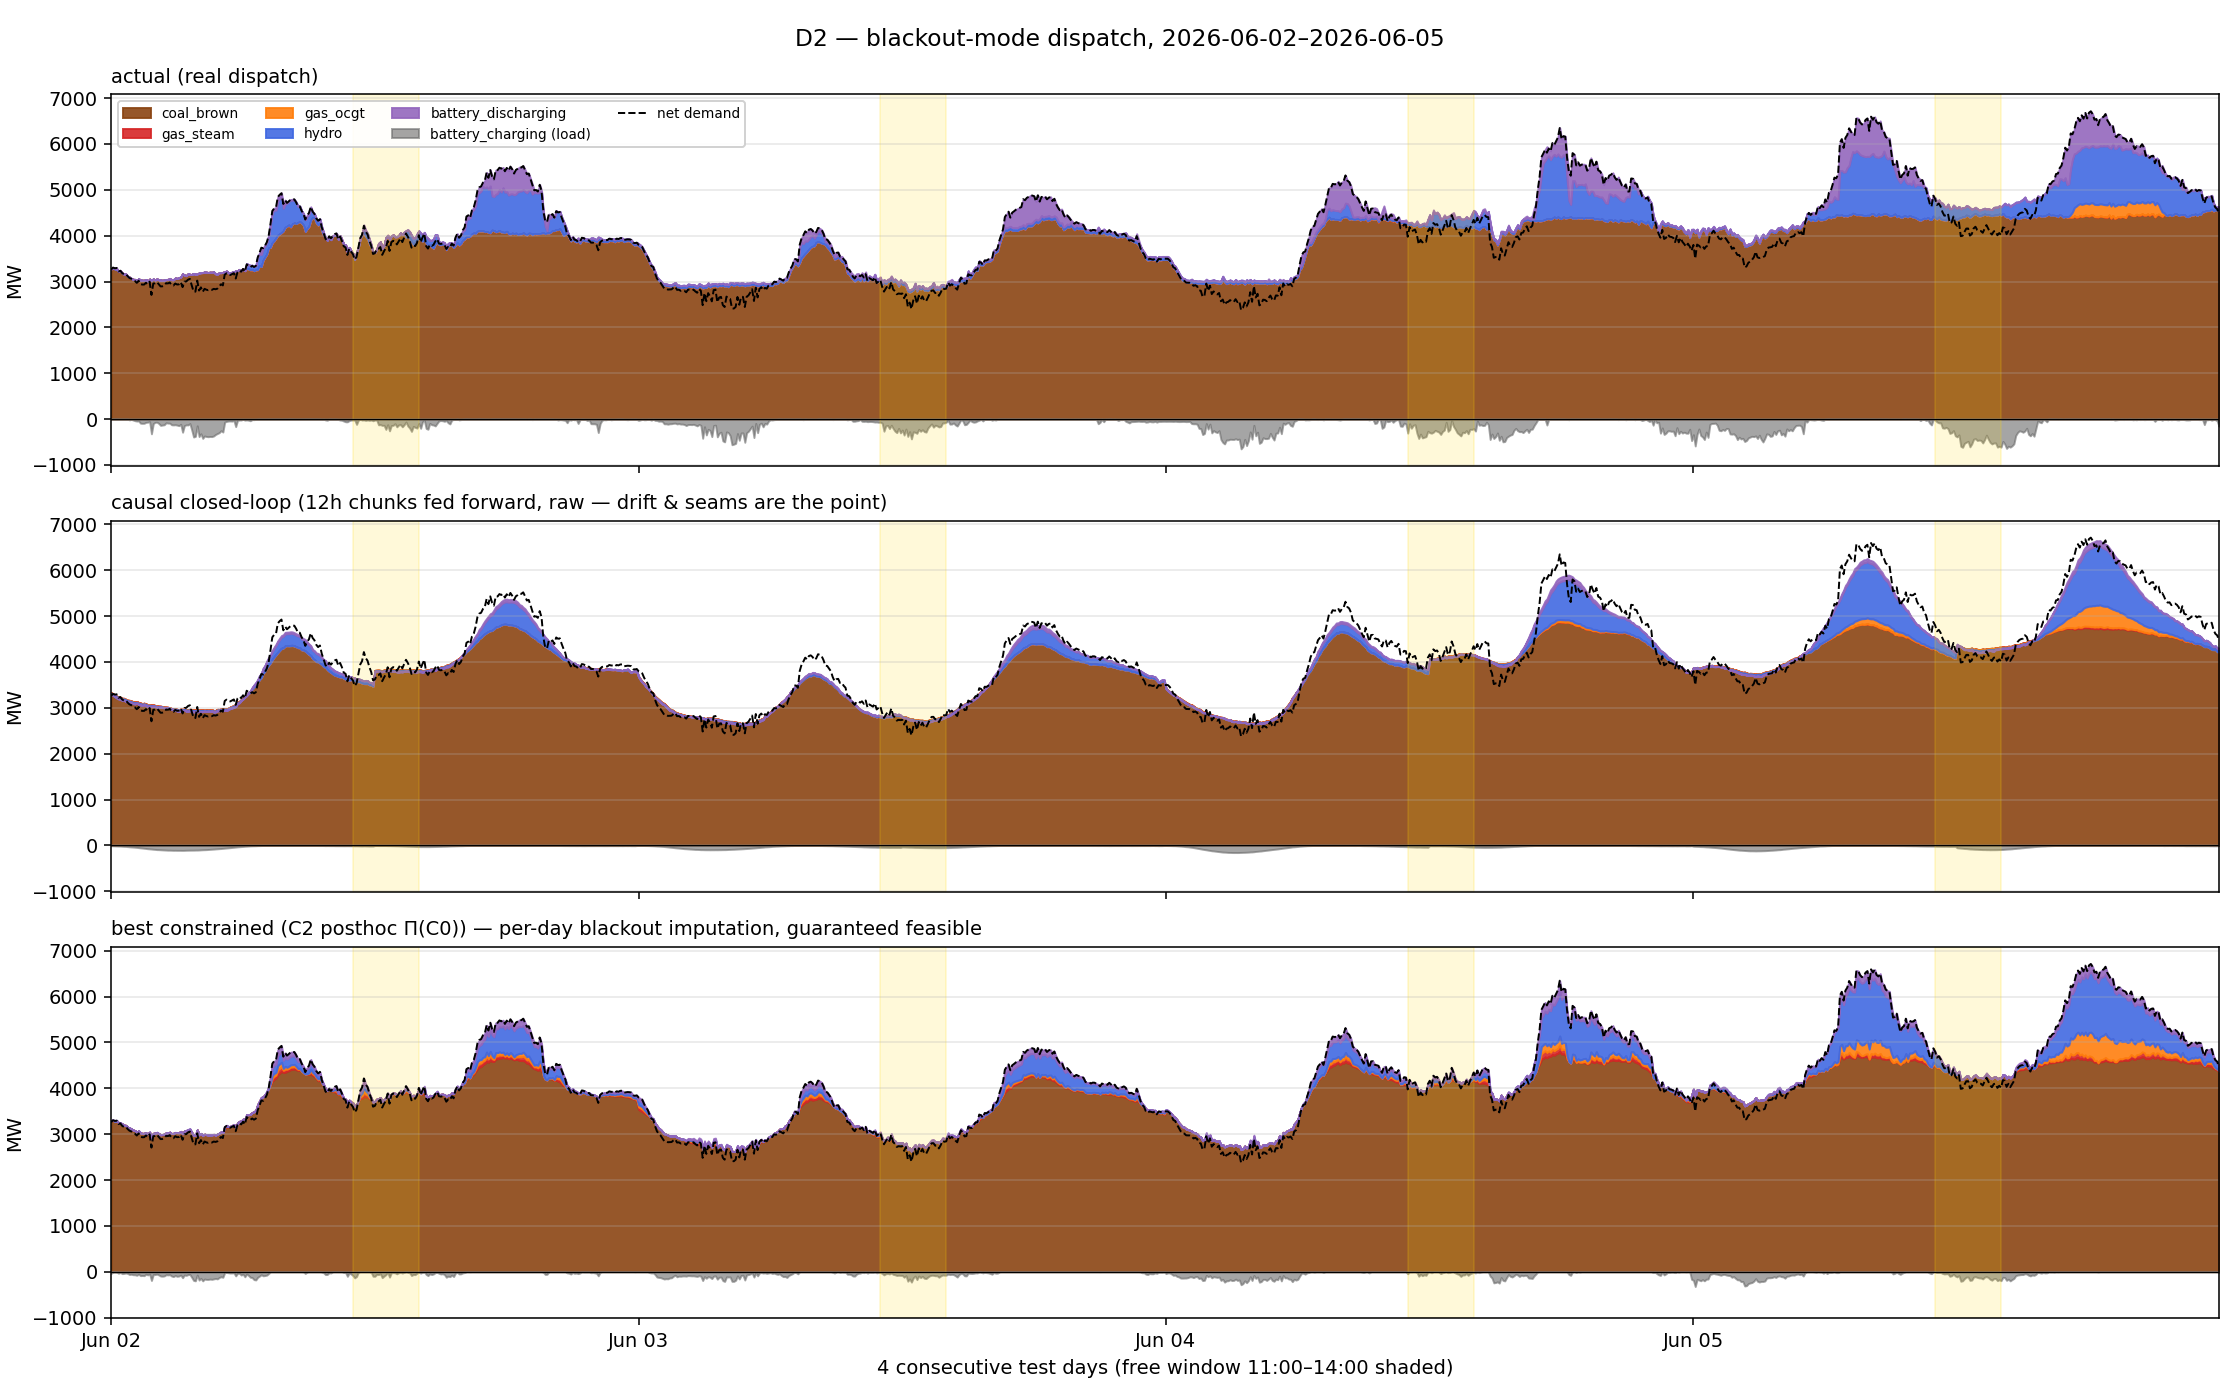

In [11]:
!python imputation/itr_figures.py --which d2
from IPython.display import Image, display
display(Image("imputation/results/itr/figure/d2_stack_4day.png"))

## 5 · D3 — counterfactual change report at q\* (Option A, nothing pinned)

Whole-day blackout, base vs shifted drivers, free-endpoint guarantee map on both
runs. Read: ΔEᵢ per fuel free/off-window, peaks, **violations must be 0**, and the
conservation check Σᵢ SIGNᵢ·ΔEᵢ ≈ shifted net-demand energy in each region.

/content/energy_modelling/imputation/itr_model.py:41: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, n_layers)
winner: C2 posthoc Π(C0) (map=proj, ckpt=itr_T4)
# D3 — counterfactual change report, FixedPercentageShift(q=3.699%)

185 test days, whole-day blackout imputation, Option A (no pinned dispatch anywhere), guarantee map = free-endpoint Π on C2 posthoc Π(C0).

| fuel | ΔE free-window (MWh) | ΔE off-window (MWh) | peak base→shift (MW) |
| --- | --- | --- | --- |
| hydro | +147215 | -305779 | 1834 → 1834 |
| coal_brown | +536082 | -333580 | 4896 → 4896 |
| gas_steam | +48361 | -26183 | 514 → 514 |
| gas_ocgt | +66903 | -71652 | 1283 → 1211 |
| battery_charging | -60462 | +76908 | 521 → 838 |
| battery_discharging | +53991 | -4755 | 365 → 674 |

**Violations (must be 0):** bal>1MW steps 2, ramp cells 0, neg cells 0, SOC days 0.

**Consistency (Σ SIGN·ΔE vs shifted 

# D3 — counterfactual change report, FixedPercentageShift(q=3.699%)

185 test days, whole-day blackout imputation, Option A (no pinned dispatch anywhere), guarantee map = free-endpoint Π on C2 posthoc Π(C0).

| fuel | ΔE free-window (MWh) | ΔE off-window (MWh) | peak base→shift (MW) |
| --- | --- | --- | --- |
| hydro | +147215 | -305779 | 1834 → 1834 |
| coal_brown | +536082 | -333580 | 4896 → 4896 |
| gas_steam | +48361 | -26183 | 514 → 514 |
| gas_ocgt | +66903 | -71652 | 1283 → 1211 |
| battery_charging | -60462 | +76908 | 521 → 838 |
| battery_discharging | +53991 | -4755 | 365 → 674 |

**Violations (must be 0):** bal>1MW steps 2, ramp cells 0, neg cells 0, SOC days 0.

**Consistency (Σ SIGN·ΔE vs shifted net-demand energy):**
free-window: dispatch +913014 MWh vs demand +913014 MWh (gap 0);  off-window: -818858 vs -818877 MWh (gap 20).


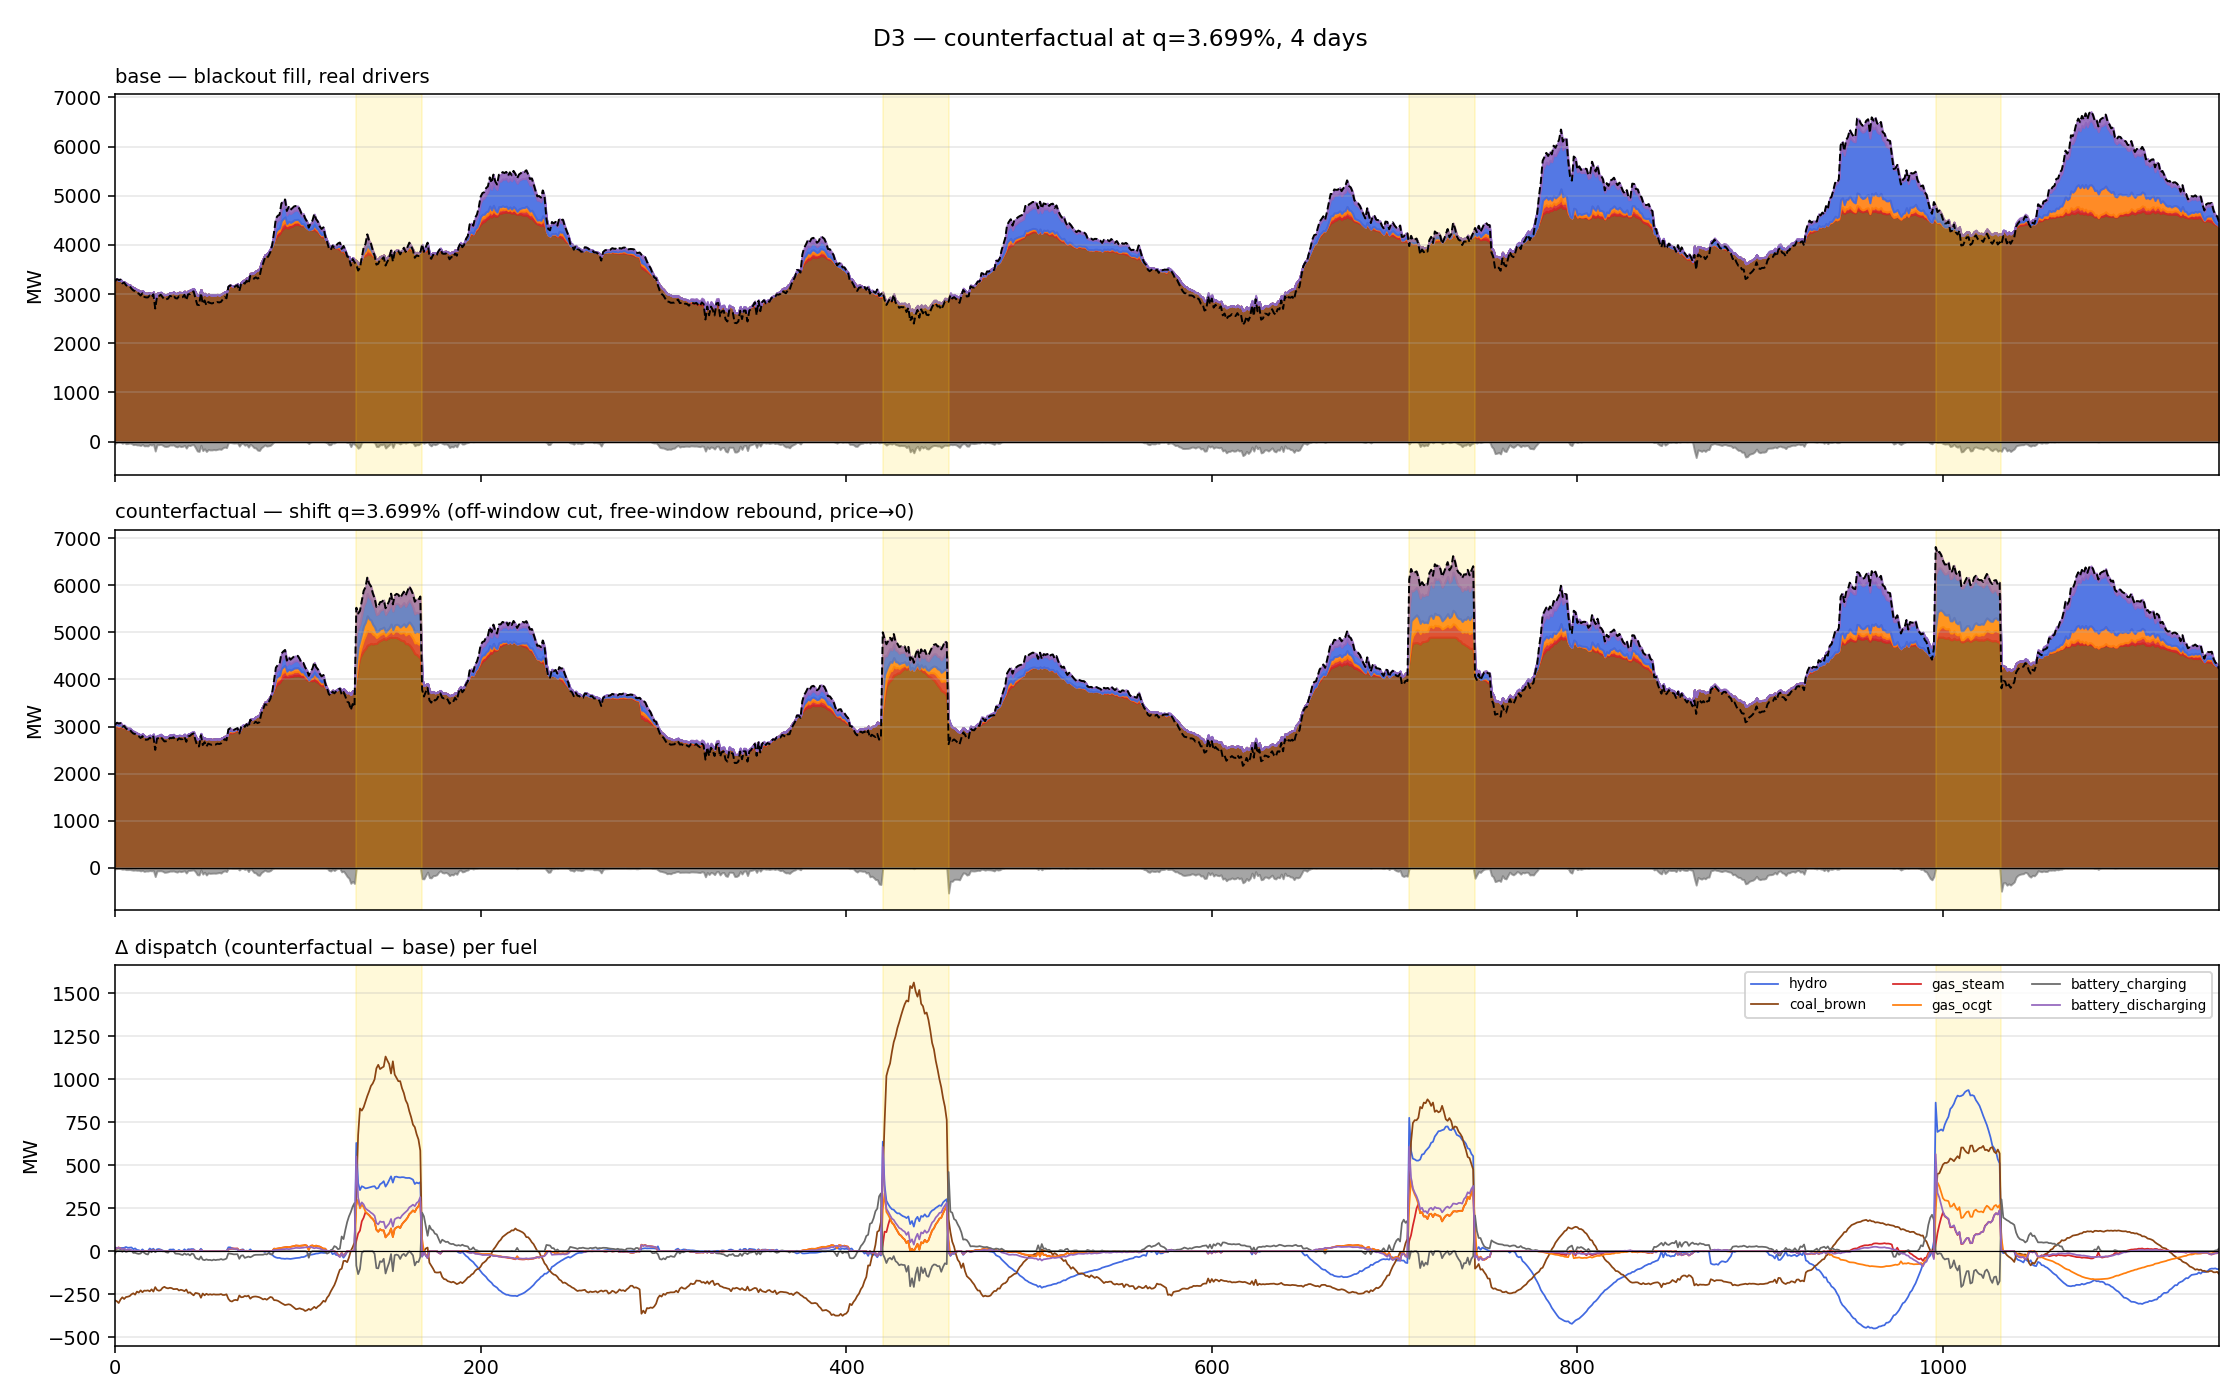

In [12]:
!python imputation/itr_figures.py --which d3
from IPython.display import Image, Markdown, display
display(Markdown(open("imputation/results/itr/d3_report.md").read()))
display(Image("imputation/results/itr/figure/d3_counterfactual.png"))

In [13]:
# === SAVE ALL WEIGHTS + RESULTS TO YOUR LOCAL MACHINE ===============================
# Colab's disk is wiped when the runtime disconnects, and this repo is cloned READ-ONLY
# (no push), so trained weights live ONLY here until you pull them out. Run this cell
# BEFORE disconnecting: it bundles every checkpoint (.pt), metrics/selection (.json),
# table (.md) and figure (.png) into ONE zip and downloads it in a single click.
import glob, zipfile, os
files_ = sorted(set(
    glob.glob("imputation/results/**/*.pt",  recursive=True) +
    glob.glob("imputation/results/**/*.json", recursive=True) +
    glob.glob("imputation/results/**/*.md",   recursive=True) +
    glob.glob("imputation/results/**/*.png",  recursive=True)))
zipname = "imputation_weights_results.zip"
with zipfile.ZipFile(zipname, "w", zipfile.ZIP_DEFLATED) as z:
    for p in files_:
        z.write(p)                       # keeps the imputation/results/... paths
print(f"bundled {len(files_)} files -> {zipname} ({os.path.getsize(zipname)/1e6:.1f} MB)")
for p in files_:
    print("  ", p)

# download it (browser); alternatively persist to Drive with the 2 commented lines
from google.colab import files
files.download(zipname)
# from google.colab import drive; drive.mount("/content/drive")
# !cp {zipname} /content/drive/MyDrive/

# ---- THEN, LOCALLY, from the repo root: -----------------------------------------
#   unzip -o ~/Downloads/imputation_weights_results.zip
# restores imputation/results/**/*.pt exactly where the scripts expect them, so
# stack_gap.py / scenario_eval.py / full_series_check.py / itr_figures.py just work.

bundled 40 files -> imputation_weights_results.zip (16.1 MB)
   imputation/results/baseline_interp.json
   imputation/results/baseline_interp_proj.json
   imputation/results/baseline_knn.json
   imputation/results/baseline_mean.json
   imputation/results/baseline_mf.json
   imputation/results/baseline_mice.json
   imputation/results/baselines.md
   imputation/results/benchmark.md
   imputation/results/bilstm_recon.json
   imputation/results/bilstm_smoke_recon.json
   imputation/results/figure/stack_gap_4day_g10.png
   imputation/results/figure/stack_gap_day40_g10.png
   imputation/results/full_series_actual.json
   imputation/results/full_series_shift_reference_q3.699.json
   imputation/results/itr/d1_constraint_table.md
   imputation/results/itr/d1_training_table.md
   imputation/results/itr/d3_report.json
   imputation/results/itr/d3_report.md
   imputation/results/itr/figure/d2_stack_4day.png
   imputation/results/itr/figure/d3_counterfactual.png
   imputation/results/itr/itr_T1.jso

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 6 · Conclusions — fill in after the run

- **T\*** = ____ (val blackout-MAE ____; ties within 5%: ____)
- **Best guaranteed-feasible** = ____ (C2 vs C3 blackout MAE ____ vs ____; tie? ____)
- Does any constrained learner beat the pro-rata and causal references? ____
- Feasibility floor: F_Π = ____, F_rayen = ____ (if F_rayen ≈ C3's MAE, the RAYEN
  single-α conservatism — not the network — is the binding cost)
- D3 at q\* = 3.699%: violations ____ (must be 0); conservation gaps ____ MWh
- Remember the tie rule: <5% relative MAE = tie; rerun only a deciding pair with seeds.